In [248]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from xgboost import plot_importance
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [249]:
df = pd.read_csv("data/raw/trading_synthetic.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

,date,clients,product,market_index,contracts,nf_volume,tons
0,2023-01-01,596,export,100.397371,3663,21245,3113550
1,2023-01-08,500,export,100.286760,3379,19598,2872150
2,2023-01-15,531,export,100.804911,3573,20723,3037050
3,2023-01-22,473,export,102.023335,3323,19273,2824550
4,2023-01-29,534,barter,101.836012,2141,6637,471020


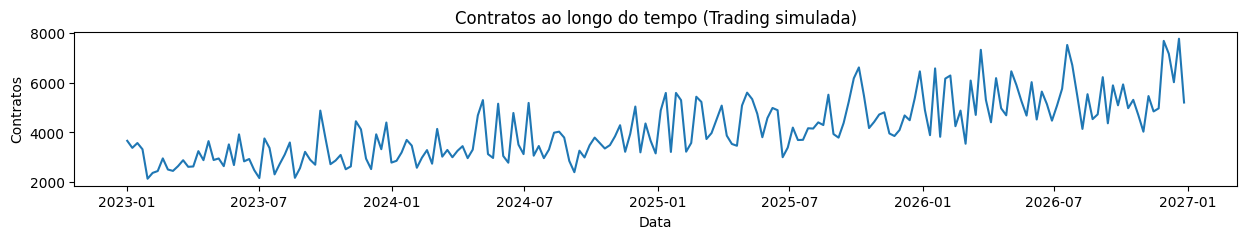

In [250]:
plt.figure(figsize=(15,2))
plt.plot(df["date"], df["contracts"])
plt.title("Contratos ao longo do tempo (Trading simulada)")
plt.xlabel("Data")
plt.ylabel("Contratos")
plt.show()

In [251]:
df_hw = df.copy()
df_hw = df_hw.set_index("date")

ts = df_hw["contracts"].asfreq("W")

train = ts[: "2025-12-31"]
test  = ts["2026-01-01":]

In [252]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=52  # semanal com sazonalidade anual
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(len(test))

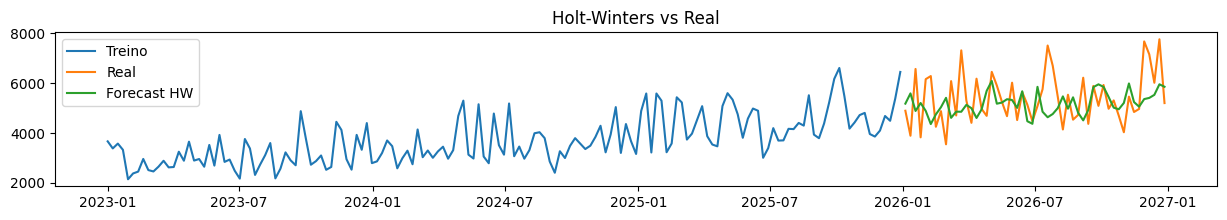

In [253]:
plt.figure(figsize=(15,2))

plt.plot(train.index, train, label="Treino")
plt.plot(test.index, test, label="Real")
plt.plot(test.index, hw_forecast, label="Forecast HW")

plt.legend()
plt.title("Holt-Winters vs Real")
plt.show()

In [254]:
hw_mape = np.mean(np.abs((test - hw_forecast) / test)) * 100
print(f"HW MAPE: {hw_mape:.2f}%")

HW MAPE: 15.85%


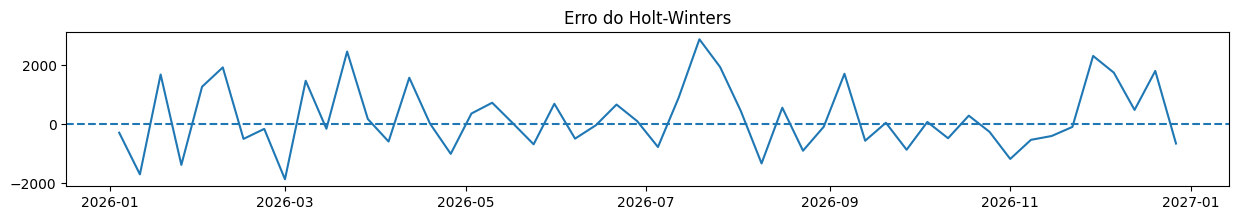

,real,forecast,erro_abs
2026-07-19,7509,4630.003126,2878.996874
2026-03-22,7314,4850.989924,2463.010076
2026-11-29,7673,5358.801182,2314.198818
2026-07-26,6698,4760.014177,1937.985823
2026-02-08,6283,4356.848923,1926.151077
2026-03-01,3545,5409.669046,1864.669046
2026-12-20,7759,5952.180597,1806.819403
2026-12-06,7154,5406.146405,1747.853595
2026-09-06,6216,4505.047018,1710.952982
2026-01-11,3889,5587.404587,1698.404587


In [255]:
erro = test - hw_forecast

plt.figure(figsize=(15,2))
plt.plot(test.index, erro)

plt.axhline(0, linestyle="--")

plt.title("Erro do Holt-Winters")
plt.show()

resultado = pd.DataFrame({
    "real": test,
    "forecast": hw_forecast
})

resultado["erro_abs"] = abs(
    resultado["real"] -
    resultado["forecast"]
)

resultado.sort_values(
    "erro_abs",
    ascending=False
).head(10)

In [256]:
naive_forecast = train.iloc[-1]

naive_forecast = pd.Series(
    [naive_forecast] * len(test),
    index=test.index
)

naive_mape = np.mean(np.abs((test - naive_forecast) / test)) * 100
print(f"NAIVE MAPE: {naive_mape:.2f}%")

NAIVE MAPE: 26.29%


In [257]:
df[["contracts", "clients", "market_index"]].corr()

,contracts,clients,market_index
contracts,1.000000,0.774596,-0.231518
clients,0.774596,1.000000,-0.369222
market_index,-0.231518,-0.369222,1.000000


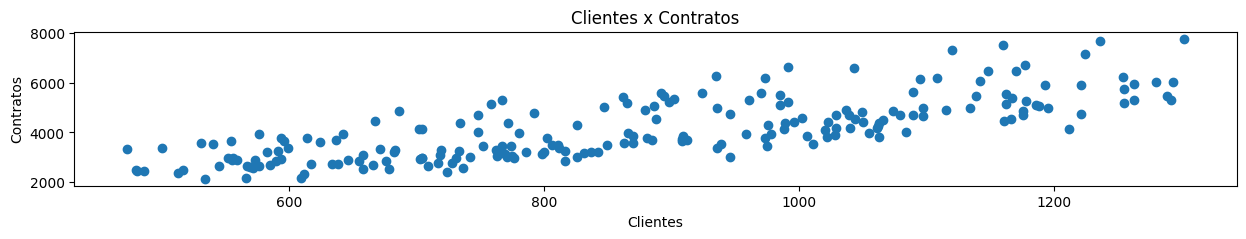

In [258]:
plt.figure(figsize=(15,2))
plt.scatter(
    df["clients"],
    df["contracts"]
)

plt.xlabel("Clientes")
plt.ylabel("Contratos")
plt.title("Clientes x Contratos")
plt.show()

In [259]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)

In [260]:
df = pd.get_dummies(
    df,
    columns=["product"],
    drop_first=True
)

print(df.columns)

Index(['date', 'clients', 'market_index', 'contracts', 'nf_volume', 'tons',
       'year', 'month', 'week', 'product_export', 'product_origination'],
      dtype='str')


In [261]:
features = [
    "clients",
    "market_index",
    "month",
    "week",
    "product_export",
    "product_origination"
]

target = "contracts"

train = df[df["date"] < "2026-01-01"]
test = df[df["date"] >= "2026-01-01"]

In [262]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    train[features],
    train[target]
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


XGB MAPE: 14.34%


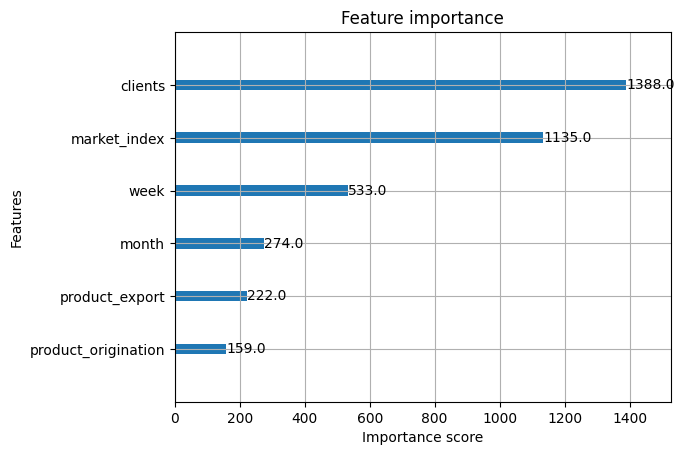

,feature,importance
4,product_export,0.742764
0,clients,0.186340
5,product_origination,0.036677
1,market_index,0.012581
3,week,0.011368
2,month,0.010270


In [263]:
pred = xgb_model.predict(
    test[features]
)

xbg_mape = np.mean(
    np.abs(
        (test[target] - pred)
        / test[target]
    )
) * 100

print(f"XGB MAPE: {xbg_mape:.2f}%")

plot_importance(xgb_model)
plt.show()

importance = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
)